Plot saved successfully to /srv/homes/onbo10/thesis_Ons/ViTPose/work_dirs/vitpose_base_surg_experiment_1/20260128_150455/thesis_val_plot.png


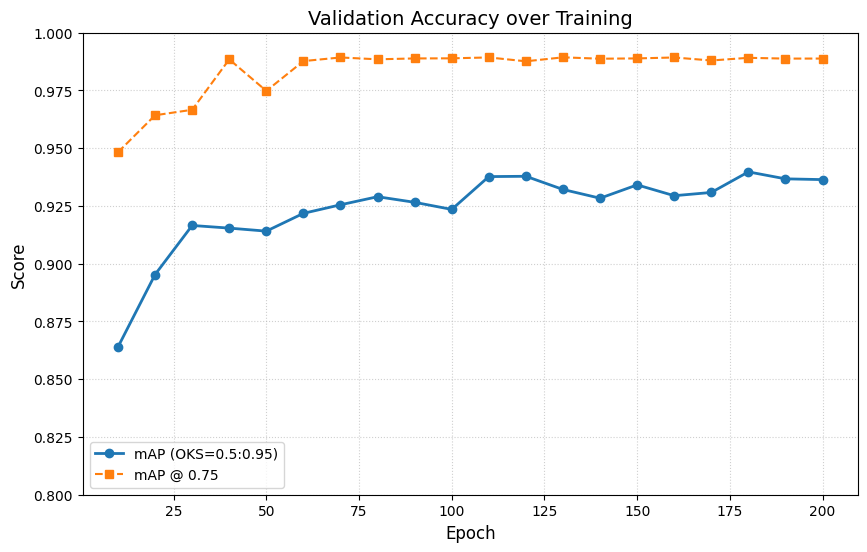

In [1]:
import json
import matplotlib.pyplot as plt

log_file = '/srv/homes/onbo10/thesis_Ons/ViTPose/work_dirs/vitpose_base_surg_experiment_1/20260128_150455/vis_data/scalars.json'
output_path = '/srv/homes/onbo10/thesis_Ons/ViTPose/work_dirs/vitpose_base_surg_experiment_1/20260128_150455/thesis_val_plot.png'

epochs = []
mAP = []
mAP_75 = []

with open(log_file, 'r') as f:
    for line in f:
        data = json.loads(line)
        # Only extract lines that contain validation metrics
        if 'coco/AP' in data and 'step' in data:
            epochs.append(data['step']) 
            mAP.append(data['coco/AP'])
            mAP_75.append(data['coco/AP .75'])

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, mAP, label='mAP (OKS=0.5:0.95)', marker='o', linewidth=2)
plt.plot(epochs, mAP_75, label='mAP @ 0.75', linestyle='--', marker='s')

plt.title('Validation Accuracy over Training', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.ylim(0.8, 1.0) 

plt.savefig(output_path, dpi=300)
print(f"Plot saved successfully to {output_path}")

In [1]:
# import json
# import matplotlib.pyplot as plt

# log_file = '/srv/homes/onbo10/thesis_Ons/ViTPose/work_dirs/vitpose_base_surg_experiment_1/20260128_150455/vis_data/scalars.json'
# output_path = '/srv/homes/onbo10/thesis_Ons/ViTPose/work_dirs/vitpose_base_surg_experiment_1/20260128_150455/thesis_train_loss_plot.png'

# epochs = []
# loss_kpt = []


# with open(log_file, 'r') as f:
#     for line in f:
#         data = json.loads(line)
#         # Only extract lines that contain validation metrics
#         if 'loss' in data and 'step' in data:
#             epochs.append(data['step']) 
#             loss_kpt.append(data['loss'])
          

# # Create the plot
# plt.figure(figsize=(10, 6))
# plt.plot(epochs, loss_kpt, label='train_loss', marker='o', linewidth=2)


# plt.title('Training loss evolution', fontsize=14)
# plt.xlabel('Epoch', fontsize=12)
# plt.ylabel('Score', fontsize=12)
# plt.grid(True, linestyle=':', alpha=0.6)
# plt.legend()
# #plt.ylim(0.8, 1.0) # Zoom in on the high-performance area

# plt.savefig(output_path, dpi=300)
# print(f"Plot saved successfully to {output_path}")

Clean plot saved to /srv/homes/onbo10/thesis_Ons/ViTPose/work_dirs/vitpose_base_surg_experiment_1/20260128_150455/thesis_train_loss_epoch_only.png
Processed 200 total epochs.


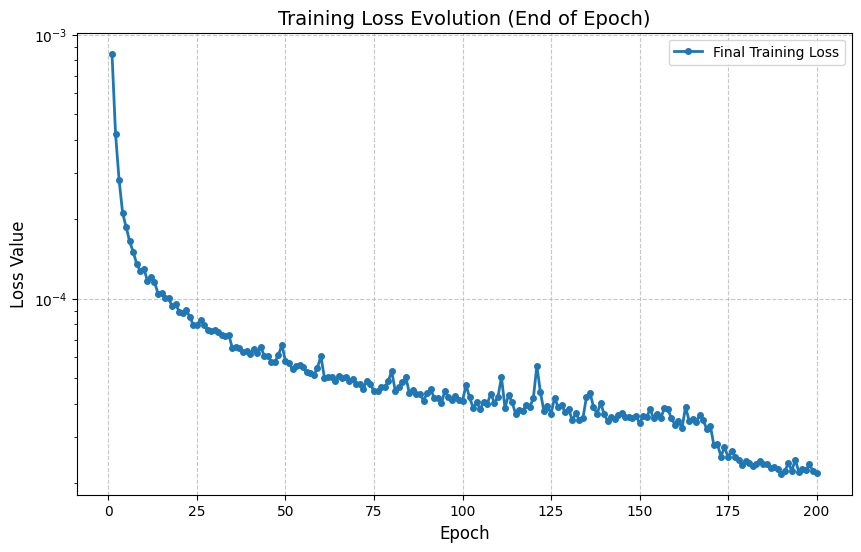

In [1]:
import json
import matplotlib.pyplot as plt

log_file = '/srv/homes/onbo10/thesis_Ons/ViTPose/work_dirs/vitpose_base_surg_experiment_1/20260128_150455/vis_data/scalars.json'
output_path = '/srv/homes/onbo10/thesis_Ons/ViTPose/work_dirs/vitpose_base_surg_experiment_1/20260128_150455/thesis_train_loss_epoch_only.png'

# Using a dictionary ensures we only keep the LAST entry for each epoch
epoch_data = {}

with open(log_file, 'r') as f:
    for line in f:
        data = json.loads(line)
        # Check if this is a training line (contains loss and epoch)
        if 'loss' in data and 'epoch' in data:
            current_epoch = data['epoch']
            # This will naturally keep overwriting until the last step of the epoch
            epoch_data[current_epoch] = data['loss']

# Sort by epoch number to ensure the line connects correctly
sorted_epochs = sorted(epoch_data.keys())
sorted_losses = [epoch_data[e] for e in sorted_epochs]

# Create the clean plot
plt.figure(figsize=(10, 6))
plt.plot(sorted_epochs, sorted_losses, label='Final Training Loss', marker='o', markersize=4, linewidth=2)

plt.title('Training Loss Evolution (End of Epoch)', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()


plt.yscale('log') 

plt.savefig(output_path, dpi=300)
print(f"Clean plot saved to {output_path}")
print(f"Processed {len(sorted_epochs)} total epochs.")

+ Custom mAP evaluation

In [1]:
import torch
from torch.utils.data import DataLoader
import numpy as np
from ultralytics.utils.metrics import kpt_iou
from ultralytics.utils.ops import xyxy2xywh
import torch
import numpy as np
from ultralytics.utils.metrics import ap_per_class
import re
import yaml
import os

In [2]:
#same as in file evaluation_utils.py but needs to fix imports first
def process_batch(pred_kpts, gt_kpts, gt_areas, sigmas, confidences, iou_thresholds):
    """
    Matches predictions to ground truths based on OKS.
    pred_kpts: [M, n_joints, 3] (x, y, conf)
    gt_kpts: [N, n_joints, 3] (x, y, visibility)
    gt_areas: [N] (areas of GT objects)
    """
    num_thresholds = len(iou_thresholds)
    num_preds = pred_kpts.shape[0]
    # correct_matrix: [num_preds, 10] (True/False for each OKS threshold)
    correct_matrix = torch.zeros(num_preds, num_thresholds, dtype=torch.bool)
    
    if num_preds == 0:
        return correct_matrix

    # Compute OKS Matrix [N, M]
    oks = kpt_iou(gt_kpts, pred_kpts, gt_areas, sigmas)

    # Matching Logic
    for i, threshold in enumerate(iou_thresholds):
        # Find matches where OKS > threshold
        matches = torch.where(oks > threshold) 
        if matches[0].shape[0] > 0:
            match_data = torch.stack([matches[0], matches[1], oks[matches]], 1).cpu().numpy()
            if match_data.shape[0] > 1:
                # Sort matches by highest OKS
                match_data = match_data[match_data[:, 2].argsort()[::-1]]
                # Ensure one GT matches only one Pred (and vice versa)
                match_data = match_data[np.unique(match_data[:, 1], return_index=True)[1]]
                match_data = match_data[np.unique(match_data[:, 0], return_index=True)[1]]
            
            correct_matrix[match_data[:, 1].astype(int), i] = True
            
    return correct_matrix

In [10]:

def evaluate_ViTPose_custom(model, test_loader, device, SIGMAS, IOU_THRESHOLDS):
    stats = []
    model.eval()
    
    
    with torch.no_grad():
        for batch in test_loader:
            # Move data to device using the model's preprocessor
            # This handles normalization (mean/std) automatically
            data = model.data_preprocessor(batch, False)
            
            # Run Inference
            # Returns a list of PoseDataSample objects
            results = model.predict(**data)
            
            for i, result in enumerate(results):
                # Extract predicted keypoints [K, 2] and scores [K]
                # These are already decoded from heatmaps to pixel coordinates
                pred_instances = result.pred_instances
                pk_coords = pred_instances.keypoints[0] # [K, 2]
                pk_scores = pred_instances.keypoint_scores[0] # [K]
                
                # Combine into [K, 3] (x, y, conf) to match your 'pk' format
                pk = torch.cat([
                    torch.from_numpy(pk_coords), 
                    torch.from_numpy(pk_scores).unsqueeze(-1)
                ], dim=1).to(device)
                
                # Get Ground Truth from the result object
                # MMPose stores GT in the same data sample
                gt_instances = result.gt_instances
                gk = torch.from_numpy(gt_instances.keypoints[0]).to(device) # [K, 2]
                gv = torch.from_numpy(gt_instances.keypoints_visible[0]).to(device) # [K]
                
                # Format GT as [K, 3] (x, y, visibility)
                gk_formatted = torch.cat([gk, gv.unsqueeze(-1)], dim=1)
                
                # Area Calculation 
                gt_bboxes = gt_instances.bboxes[0] 
                #internally in MMpose the bboxes are comverted to the form [x1,y1,x2,y2]
                area = (gt_bboxes[2] - gt_bboxes[0]) * (gt_bboxes[3] - gt_bboxes[1])
                area = torch.tensor([area], device=device)
                
                # Object Confidence, mean of the keypoints scores
                obj_conf = pk[:, 2].mean().unsqueeze(0)
                
                # Matching Logic
                tp_matrix = process_batch(
                    pk.unsqueeze(0), 
                    gk_formatted.unsqueeze(0), 
                    area, 
                    SIGMAS, 
                    obj_conf, 
                    IOU_THRESHOLDS
                )
                
                stats.append((tp_matrix.cpu(), obj_conf.cpu(), torch.zeros(1), torch.zeros(1)))

    # mAP Calculation 
    if len(stats) > 0:
        tp, conf, pcls, gcls = [torch.cat(x, 0).numpy() for x in zip(*stats)]
        results = ap_per_class(tp, conf, pcls, gcls, plot=False)
        
        # results structure: (tp, fp, p, r, f1, ap, unique_classes)
        ap = results[5] 
        map50 = ap[:, 0].mean() 
        map50_95 = ap.mean()
        
        return len(stats), results[2].mean(), results[3].mean(), map50, map50_95
    else:
        return None

In [11]:
import torch
from mmengine.dataset import DefaultSampler
from mmengine.runner import load_checkpoint
from mmpose.apis import init_model
from mmpose.datasets import build_dataset
from torch.utils.data import DataLoader
from mmengine.dataset import pseudo_collate



config_file = '/srv/homes/onbo10/thesis_Ons/mmpose/configs/body_2d_keypoint/topdown_heatmap/surgpose/vitpose_surg_7kpt.py'
checkpoint_file = '/srv/homes/onbo10/thesis_Ons/ViTPose/work_dirs/vitpose_base_surg_experiment_1/best_coco_AP_epoch_180.pth'
device = 'cuda:0'
SIGMAS =  torch.tensor([0.026, 0.025, 0.025, 0.035, 0.035, 0.079, 0.079]).to(device) 
IOU_THRESHOLDS = torch.linspace(0.5, 0.95, 10).to(device)

#Initialize the finetuned model
model = init_model(config_file, checkpoint_file, device=device)
model.eval()
dataset = build_dataset(model.cfg.test_dataloader.dataset)
dataloader = DataLoader(
    dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    collate_fn=pseudo_collate
)

num_images, precision, recall, map50, map50_95 = evaluate_ViTPose_custom(model,dataloader,device,SIGMAS,IOU_THRESHOLDS)
#Write tgis into a display function at some point
print("\n" + "="*40)
print("ViTpose TEST EVALUATION RESULTS")
print("="*40)
print(f"Total Images: {num_images}")
print(f"Precision:    {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"mAP@50:       {map50:.4f}")
print(f"mAP@50-95:    {map50_95:.4f}")
print("="*40)

Loads checkpoint by local backend from path: /srv/homes/onbo10/thesis_Ons/ViTPose/work_dirs/vitpose_base_surg_experiment_1/best_coco_AP_epoch_180.pth
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


/srv/homes/onbo10/.local/lib/python3.8/site-packages/ultralytics/utils/metrics.py:183: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sigma = torch.tensor(sigma, device=kpt1.device, dtype=kpt1.dtype)  # (17, )



ViTpose TEST EVALUATION RESULTS
Total Images: 3073
Precision:    0.9997
Recall:       0.9997
mAP@50:       0.9950
mAP@50-95:    0.9928
